# Phân loại ĐA LỚP bằng Softmax — minh họa hướng đối tượng

Nâng cấp từ `logistic-regression-oop.ipynb`. Bám note **[[softmax]]** (slide L4 Phần 03 — TS. Cao Tiến Dũng).

**So với bản nhị phân:**

| Nhị phân (sigmoid) | Đa lớp (softmax) |
|---|---|
| `sigmoid` → 1 xác suất | `softmax` → **K xác suất, tổng = 1** |
| `w` (vector), `b` (số) | **`W` ma trận (p×K), `b` vector (K)** |
| Binary Cross-Entropy | **Categorical Cross-Entropy** + nhãn **one-hot** |
| gradient `(σ−y)·x` | gradient `Xᵀ·(S − Y_onehot)` — *cùng dạng đẹp* |
| 1 đường ranh giới | **nhiều vùng quyết định** |

**Các hàm tường minh** trong lớp `SoftmaxRegressionGD`:
`softmax(Z)` · `net_input(X)` · `predict_proba(X)` · `predict(X)` · `cross_entropy(X, Y)` · `gradient(X, Y)` · `fit(X, y)` (dừng khi `max|đạo hàm| < 1e-5`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False

## 1) Mô hình Softmax — hướng đối tượng

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \qquad L = -\frac{1}{m}\sum \text{one-hot}(y)\cdot \log(S)$$

In [2]:
class SoftmaxRegressionGD:
    """Hồi quy Softmax (Logistic đa thức) — phân loại K lớp bằng Gradient Descent."""

    def __init__(self, lr=0.5, max_epochs=200_000, tol=1e-5,
                 decay=0.9, decay_every=1000, min_lr=0.01):
        self.lr0 = lr                 # tốc độ học ban đầu α₀
        self.lr = lr                  # tốc độ học hiện tại (sẽ giảm dần)
        self.decay = decay            # hệ số decay (×0.9 mỗi chu kỳ)
        self.decay_every = decay_every  # giảm lr sau mỗi bao nhiêu epoch
        self.min_lr = min_lr          # SÀN lr — không cho tụt về 0 (kẻo ngừng học)
        self.max_epochs = max_epochs  # trần vòng lặp (an toàn)
        self.tol = tol                # DỪNG: max|đạo hàm| < tol
        self.W = None                 # trọng số (p đặc trưng × K lớp)
        self.b = None                 # bias (K lớp)
        self.K = None                 # số lớp
        self.history = []             # (epoch, W, b, loss, grad_max, lr) để vẽ

    # ---- các hàm toán tường minh -------------------------------------
    @staticmethod
    def softmax(Z):
        """σ(Z)_i = e^z_i / Σ e^z_j, theo TỪNG HÀNG. Trừ max để ổn định số học."""
        Z = Z - Z.max(axis=1, keepdims=True)     # không đổi kết quả, tránh tràn exp
        E = np.exp(Z)
        return E / E.sum(axis=1, keepdims=True)   # mỗi hàng cộng lại = 1

    @staticmethod
    def one_hot(y, K):
        """Nhãn lớp → vector one-hot. Vd lớp 2 (K=3) → [0,0,1]."""
        Y = np.zeros((len(y), K))
        Y[np.arange(len(y)), y.astype(int)] = 1
        return Y

    def net_input(self, X):
        """Z = X·W + b  → ma trận (m mẫu × K lớp) các logit."""
        return X @ self.W + self.b

    def predict_proba(self, X):
        """K xác suất mỗi mẫu = softmax(Z)."""
        return self.softmax(self.net_input(X))

    def predict(self, X):
        """Chọn lớp có xác suất CAO NHẤT (argmax)."""
        return np.argmax(self.predict_proba(X), axis=1)

    def cross_entropy(self, X, Y):
        """Categorical Cross-Entropy: L = −mean Σ Y·log(S)."""
        S = self.predict_proba(X)
        eps = 1e-12
        return -np.mean(np.sum(Y * np.log(S + eps), axis=1))

    def gradient(self, X, Y):
        """Đạo hàm rút gọn (giống nhị phân, chỉ đổi sang ma trận):
              ∂L/∂W = (1/m) Xᵀ (S − Y)
              ∂L/∂b = (1/m) Σ (S − Y)
        """
        m = X.shape[0]
        error = self.predict_proba(X) - Y        # S − one-hot = sai số (m×K)
        grad_W = (X.T @ error) / m               # (p×K)
        grad_b = error.mean(axis=0)              # (K,)
        return grad_W, grad_b

    # ---- huấn luyện --------------------------------------------------
    def fit(self, X, y):
        self.K = int(y.max()) + 1
        Y = self.one_hot(y, self.K)              # nhãn one-hot (m×K)
        self.W = np.zeros((X.shape[1], self.K))  # khởi tạo 0
        self.b = np.zeros(self.K)
        self.lr = self.lr0                       # reset lr (cho phép fit lại)
        self.history.clear()

        for epoch in range(self.max_epochs):
            # 📉 LEARNING-RATE DECAY: mỗi decay_every epoch, giảm lr (nhưng không dưới min_lr)
            if epoch > 0 and epoch % self.decay_every == 0:
                self.lr = max(self.lr * self.decay, self.min_lr)
                if epoch % 10_000 == 0:          # in thưa cho gọn
                    print(f"   ↓ epoch {epoch}: lr = {self.lr:.4f}")

            grad_W, grad_b = self.gradient(X, Y)

            self.W -= self.lr * grad_W           # cập nhật với lr hiện tại
            self.b -= self.lr * grad_b

            loss = self.cross_entropy(X, Y)
            grad_max = max(np.max(np.abs(grad_W)), np.max(np.abs(grad_b)))
            self.history.append((epoch, self.W.copy(), self.b.copy(), loss, grad_max, self.lr))

            # ĐIỀU KIỆN DỪNG: trị tuyệt đối mọi đạo hàm < 1e-5
            if grad_max < self.tol:
                print(f"✅ Dừng ở epoch {epoch}: max|đạo hàm| = {grad_max:.2e} "
                      f"< tol = {self.tol}  | loss = {loss:.6f}  | lr = {self.lr:.4f}")
                break
        else:
            print(f"⚠️ Chạm trần {self.max_epochs} epoch (max|đạo hàm| = {grad_max:.2e}).")
        return self

## 2) Dữ liệu minh họa — 3 lớp, 2 đặc trưng (để vẽ vùng quyết định)

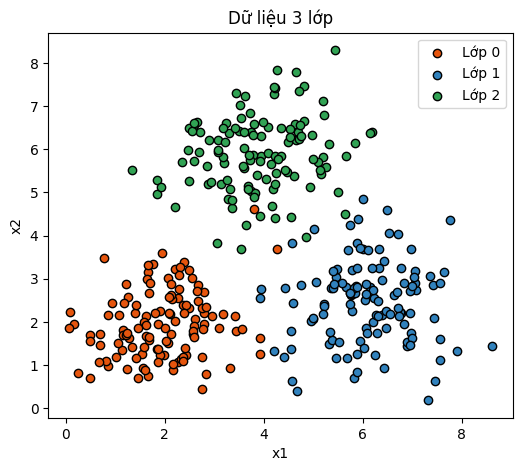

In [3]:
def make_data(n_per=120, seed=42):
    """3 cụm Gaussian (3 lớp) đặt ở 3 góc → tách được nhưng có chồng nhẹ."""
    rng = np.random.default_rng(seed)
    centers = np.array([[2.0, 2.0], [6.0, 2.5], [4.0, 6.0]])   # 3 tâm lớp
    X, y = [], []
    for k, c in enumerate(centers):
        X.append(rng.normal(c, 0.9, size=(n_per, 2)))
        y.append(np.full(n_per, k))
    return np.vstack(X), np.concatenate(y)

X, y = make_data()
colors = np.array(["#e6550d", "#3182bd", "#31a354"])   # lớp 0,1,2

plt.figure(figsize=(6, 5))
for k in range(3):
    plt.scatter(X[y == k, 0], X[y == k, 1], c=colors[k], edgecolor="k", label=f"Lớp {k}")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.title("Dữ liệu 3 lớp")
plt.show()

## 3) Huấn luyện (dừng khi `max|đạo hàm| < 1e-5`)

In [4]:
# decay=0.9 mỗi 1000 epoch → lr giảm dần (bước đầu nhanh, về sau tinh chỉnh).
# min_lr=0.2: SÀN lr. Dữ liệu này tách gần hoàn hảo → gradient chỉ về 0 khi trọng số → ∞
# (rất chậm). Nếu để lr tụt về ~0, model NGỪNG học và không bao giờ đạt tol → phải đặt sàn.
model = SoftmaxRegressionGD(lr=0.5, max_epochs=200_000, tol=1e-5,
                            decay=0.9, decay_every=1000, min_lr=0.2)
model.fit(X, y)

acc = (model.predict(X) == y).mean()
print(f"\nSố lớp K = {model.K}")
print(f"W shape = {model.W.shape} (p đặc trưng × K lớp) | b shape = {model.b.shape}")
print(f"Độ chính xác trên tập huấn luyện: {acc:.2%}")

print("\nVí dụ dự đoán — softmax trả K xác suất (tổng = 1):")
for xi in [[2, 2], [6, 2.5], [4, 6], [4, 4]]:
    p = model.predict_proba(np.array([xi]))[0]
    print(f"  x = {xi!s:<10} → P = [{p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f}] "
          f"(tổng={p.sum():.2f}) → lớp {p.argmax()}")

   ↓ epoch 10000: lr = 0.2000


   ↓ epoch 20000: lr = 0.2000


   ↓ epoch 30000: lr = 0.2000


   ↓ epoch 40000: lr = 0.2000


   ↓ epoch 50000: lr = 0.2000


   ↓ epoch 60000: lr = 0.2000


   ↓ epoch 70000: lr = 0.2000


   ↓ epoch 80000: lr = 0.2000


   ↓ epoch 90000: lr = 0.2000


   ↓ epoch 100000: lr = 0.2000
✅ Dừng ở epoch 100064: max|đạo hàm| = 1.00e-05 < tol = 1e-05  | loss = 0.047360  | lr = 0.2000

Số lớp K = 3
W shape = (2, 3) (p đặc trưng × K lớp) | b shape = (3,)
Độ chính xác trên tập huấn luyện: 97.50%

Ví dụ dự đoán — softmax trả K xác suất (tổng = 1):
  x = [2, 2]     → P = [1.00, 0.00, 0.00] (tổng=1.00) → lớp 0
  x = [6, 2.5]   → P = [0.00, 1.00, 0.00] (tổng=1.00) → lớp 1
  x = [4, 6]     → P = [0.00, 0.00, 1.00] (tổng=1.00) → lớp 2
  x = [4, 4]     → P = [0.13, 0.05, 0.82] (tổng=1.00) → lớp 2


## 4) Vẽ VÙNG quyết định (decision regions)

Khác nhị phân (1 đường thẳng), softmax chia mặt phẳng thành **K vùng** — mỗi điểm gán cho lớp có xác suất cao nhất.

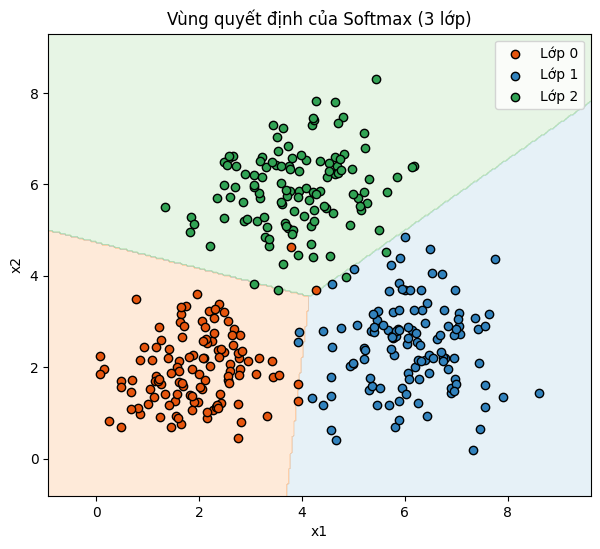

In [5]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)     # lớp dự đoán tại mỗi điểm lưới

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.25,
                 cmap=ListedColormap(["#fdae6b", "#9ecae1", "#a1d99b"]))
    for k in range(model.K):
        plt.scatter(X[y == k, 0], X[y == k, 1], c=colors[k], edgecolor="k", label=f"Lớp {k}")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title("Vùng quyết định của Softmax (3 lớp)")
    plt.legend(); plt.show()

plot_decision_regions(model, X, y)

## 5) Đường biên tiến hóa qua n lần huấn luyện

Vẽ **đường biên giữa các vùng** tại nhiều mốc epoch → thấy mô hình "nắn" dần ranh giới.

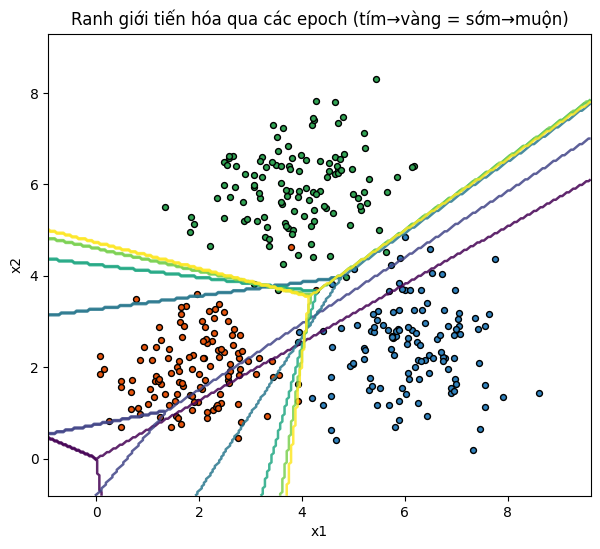

In [6]:
def plot_boundary_evolution(model, X, y, n_snap=6):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                         np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]

    last = len(model.history) - 1
    idxs = np.unique(np.geomspace(1, last + 1, n_snap).astype(int) - 1)

    plt.figure(figsize=(7, 6))
    for k in range(model.K):
        plt.scatter(X[y == k, 0], X[y == k, 1], c=colors[k], edgecolor="k", s=18)
    cmap = plt.cm.viridis
    for i, idx in enumerate(idxs):
        _, W, b, _, _, _ = model.history[idx]     # (epoch, W, b, loss, grad_max, lr)
        Z = np.argmax(grid @ W + b, axis=1).reshape(xx.shape)
        # vẽ ranh giới = nơi lớp dự đoán đổi → dùng contour trên Z
        plt.contour(xx, yy, Z, levels=[0.5, 1.5], colors=[cmap(i / max(len(idxs)-1, 1))],
                    linewidths=1.8, alpha=0.85)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title("Ranh giới tiến hóa qua các epoch (tím→vàng = sớm→muộn)")
    plt.show()

plot_boundary_evolution(model, X, y)

## 6) Hàm chi phí giảm dần

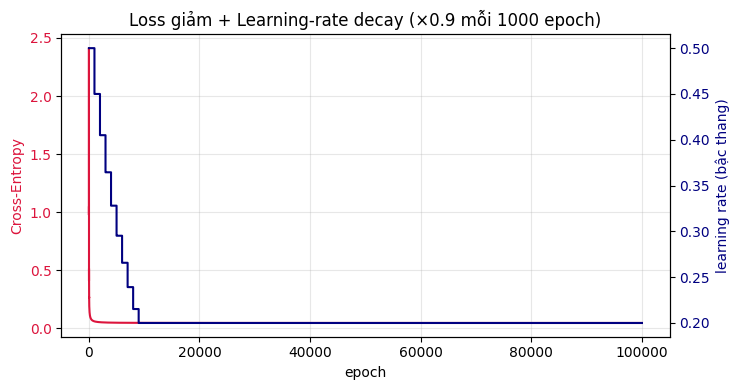

lr: 0.5 (đầu) → 0.2000 (cuối, sau decay)


In [7]:
epochs = [h[0] for h in model.history]
losses = [h[3] for h in model.history]
lrs    = [h[5] for h in model.history]   # learning rate tại mỗi epoch

fig, ax1 = plt.subplots(figsize=(7.5, 4))
ax1.plot(epochs, losses, color="crimson", label="Cross-Entropy")
ax1.set_xlabel("epoch"); ax1.set_ylabel("Cross-Entropy", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson"); ax1.grid(alpha=0.3)

ax2 = ax1.twinx()                              # trục phải cho learning rate
ax2.step(epochs, lrs, color="navy", where="post", label="learning rate")
ax2.set_ylabel("learning rate (bậc thang)", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")

plt.title("Loss giảm + Learning-rate decay (×0.9 mỗi 1000 epoch)")
fig.tight_layout(); plt.show()
print(f"lr: {model.lr0} (đầu) → {model.lr:.4f} (cuối, sau decay)")

## 7) Đánh giá đa lớp — Confusion Matrix K×K & báo cáo

Đa lớp: confusion matrix **K×K** (đường chéo = đoán đúng). Precision/Recall/F1 tính **cho từng lớp** (one-vs-rest), rồi lấy trung bình (**macro** = trung bình đều các lớp).

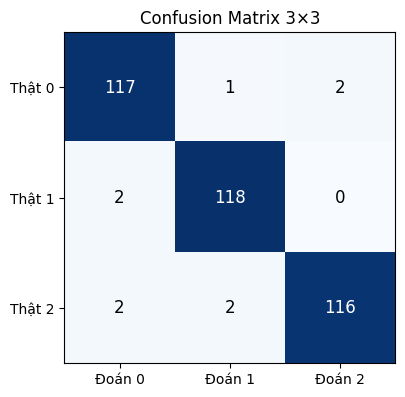

  Lớp  Precision   Recall      F1  Support
    0      0.967    0.975   0.971      120
    1      0.975    0.983   0.979      120
    2      0.983    0.967   0.975      120
macro      0.975    0.975   0.975

Accuracy tổng = 0.975


In [8]:
def confusion_matrix_multi(y_true, y_pred, K):
    """Ma trận K×K: cm[i, j] = số mẫu THẬT lớp i bị ĐOÁN lớp j."""
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true.astype(int), y_pred.astype(int)):
        cm[t, p] += 1
    return cm

y_pred = model.predict(X)
K = model.K
cm = confusion_matrix_multi(y, y_pred, K)

# vẽ heatmap
fig, ax = plt.subplots(figsize=(5, 4.3))
ax.imshow(cm, cmap="Blues")
for i in range(K):
    for j in range(K):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
ax.set_xticks(range(K), [f"Đoán {k}" for k in range(K)])
ax.set_yticks(range(K), [f"Thật {k}" for k in range(K)])
ax.set_title("Confusion Matrix 3×3")
plt.show()

# Precision/Recall/F1 từng lớp (one-vs-rest) + macro
print(f"{'Lớp':>5} {'Precision':>10} {'Recall':>8} {'F1':>7} {'Support':>8}")
Ps, Rs, Fs = [], [], []
for k in range(K):
    TP = cm[k, k]
    FP = cm[:, k].sum() - TP        # cột k trừ đường chéo = bị đoán nhầm thành k
    FN = cm[k, :].sum() - TP        # hàng k trừ đường chéo = lớp k bị đoán ra lớp khác
    P = TP / (TP + FP) if TP + FP else 0
    R = TP / (TP + FN) if TP + FN else 0
    F = 2 * P * R / (P + R) if P + R else 0
    Ps.append(P); Rs.append(R); Fs.append(F)
    print(f"{k:>5} {P:>10.3f} {R:>8.3f} {F:>7.3f} {cm[k].sum():>8}")
print(f"{'macro':>5} {np.mean(Ps):>10.3f} {np.mean(Rs):>8.3f} {np.mean(Fs):>7.3f}")
print(f"\nAccuracy tổng = {np.trace(cm) / cm.sum():.3f}")

## ✅ Tóm tắt

- **Softmax** = tổng quát hóa sigmoid cho **K lớp**: K logit → K xác suất (tổng=1) → chọn `argmax`. Khi K=2 suy biến về sigmoid.
- **Cross-Entropy + one-hot** thay cho Binary Cross-Entropy; gradient vẫn dạng đẹp `Xᵀ(S − Y)`.
- Ranh giới đa lớp = **nhiều vùng** thay vì 1 đường.
- Đánh giá: **confusion matrix K×K**, Precision/Recall/F1 **từng lớp** rồi lấy **macro**.
- Liên hệ note: [[softmax]] · [[logistic-regression]] · [[danh-gia-mo-hinh]] · [[encode-categorical]] (one-hot).